# Clasificación de niveles de actividad FIRMS

Target: `nivel_actividad_firms`. Predictores: meteorología, contexto y FIRMS previo. Se prohíbe `cantidad_detecciones` contemporánea. Los niveles describen actividad FIRMS, no riesgo ni incendios confirmados.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,balanced_accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
RUTA=Path("data/processed/modelado/dataset_modelado_nivel_actividad_firms.parquet")
if not RUTA.exists():RUTA=Path("dataset_modelado_nivel_actividad_firms.parquet")
datos=pd.read_parquet(RUTA);datos.fecha_inicio_semana=pd.to_datetime(datos.fecha_inicio_semana)
print("pandas",pd.__version__,"sklearn",sklearn.__version__,"dimensiones",datos.shape)

pandas 3.0.1 sklearn 1.8.0 dimensiones (7923, 19)


## 1. Predictores y leakage

`mes` es categórica; no se agregan estación y semana del año para evitar redundancia temporal. Las listas son explícitas.

In [2]:
CAT=["departamento","mes"]
METEO=["temperature_2m_max_mean_weekly","relative_humidity_2m_min_mean_weekly","wind_speed_10m_max_mean_weekly","precipitation_sum_weekly"]
LAGS=[f"cantidad_detecciones_lag{i}" for i in range(1,5)]
HIST=LAGS+["promedio_detecciones_ultimas_4_semanas","max_detecciones_ultimas_4_semanas","semanas_con_actividad_ultimas_4"]
NUM=METEO+HIST;XCOL=CAT+NUM;TARGET="nivel_actividad_firms";PROH={"cantidad_detecciones","cantidad_detecciones_hist",TARGET,"nivel_actividad_firms_codigo"}
assert PROH.isdisjoint(XCOL) and not datos[XCOL+[TARGET]].isna().any().any();print("Control de leakage superado:",XCOL)

Control de leakage superado: ['departamento', 'mes', 'temperature_2m_max_mean_weekly', 'relative_humidity_2m_min_mean_weekly', 'wind_speed_10m_max_mean_weekly', 'precipitation_sum_weekly', 'cantidad_detecciones_lag1', 'cantidad_detecciones_lag2', 'cantidad_detecciones_lag3', 'cantidad_detecciones_lag4', 'promedio_detecciones_ultimas_4_semanas', 'max_detecciones_ultimas_4_semanas', 'semanas_con_actividad_ultimas_4']


## 2. Partición aleatoria principal

70% train, 15% validation y 15% test mediante divisiones estratificadas reproducibles. Test queda reservado hasta elegir el modelo por F1 macro en validation.

In [3]:
RS=42;ORDEN=["Sin actividad","Bajo","Moderado","Alto"]
itr,temp=train_test_split(datos.index,test_size=.30,random_state=RS,stratify=datos[TARGET]);ival,itest=train_test_split(temp,test_size=.50,random_state=RS,stratify=datos.loc[temp,TARGET])
train=datos.loc[itr];val=datos.loc[ival];test=datos.loc[itest]
assert set(itr).isdisjoint(ival) and set(itr).isdisjoint(itest) and set(ival).isdisjoint(itest)
print(len(train),len(val),len(test));pd.concat({"train":train[TARGET].value_counts(),"validation":val[TARGET].value_counts(),"test reservado":test[TARGET].value_counts()},axis=1).reindex(ORDEN)

5546 1188 1189


,train,validation,test reservado
nivel_actividad_firms,,,
Sin actividad,3477,745,745
Bajo,866,185,186
Moderado,886,190,190
Alto,317,68,68


## 3. Pipelines y ajuste sólo con train

In [4]:
prep_lr=ColumnTransformer([("cat",OneHotEncoder(handle_unknown="ignore"),CAT),("num",StandardScaler(),NUM)])
prep_rf=ColumnTransformer([("cat",OneHotEncoder(handle_unknown="ignore"),CAT),("num","passthrough",NUM)])
modelos={
"Dummy":Pipeline([("modelo",DummyClassifier(strategy="most_frequent",random_state=RS))]),
"Regresión Logística":Pipeline([("pre",prep_lr),("modelo",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RS))]),
"Random Forest":Pipeline([("pre",prep_rf),("modelo",RandomForestClassifier(n_estimators=300,min_samples_leaf=2,class_weight="balanced_subsample",random_state=RS,n_jobs=-1))])}
for mod in modelos.values():mod.fit(train[XCOL],train[TARGET])

In [5]:
def metr(y,p):return {"Accuracy":accuracy_score(y,p),"Balanced Accuracy":balanced_accuracy_score(y,p),"Precision macro":precision_score(y,p,average="macro",zero_division=0),"Recall macro":recall_score(y,p,average="macro",zero_division=0),"F1 macro":f1_score(y,p,average="macro",zero_division=0),"F1 weighted":f1_score(y,p,average="weighted",zero_division=0)}
predval={k:v.predict(val[XCOL]) for k,v in modelos.items()};tabval=pd.DataFrame({k:metr(val[TARGET],p) for k,p in predval.items()}).T;tabval.round(4)

,Accuracy,Balanced Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted
Dummy,0.6271,0.2500,0.1568,0.2500,0.1927,0.4834
Regresión Logística,0.4773,0.4126,0.3507,0.4126,0.3528,0.5099
Random Forest,0.6094,0.3645,0.4073,0.3645,0.3660,0.5586


## 4. Validation: matrices y métricas por clase

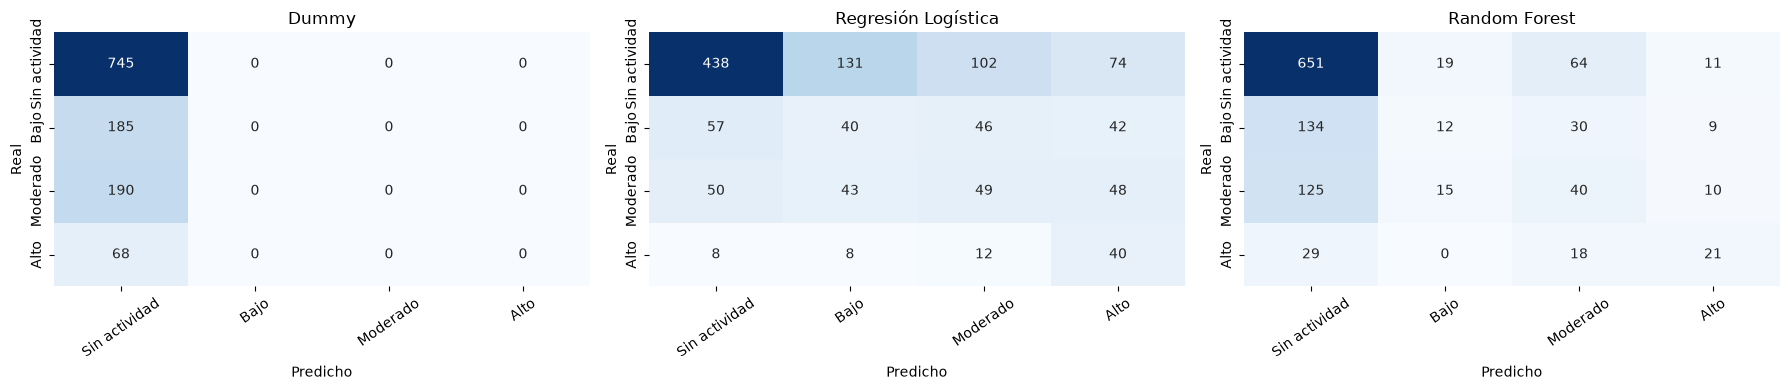


 Dummy


,precision,recall,f1-score,support
Sin actividad,0.6271,1.0,0.7708,745.0
Bajo,0.0000,0.0,0.0000,185.0
Moderado,0.0000,0.0,0.0000,190.0
Alto,0.0000,0.0,0.0000,68.0



 Regresión Logística


,precision,recall,f1-score,support
Sin actividad,0.7920,0.5879,0.6749,745.0
Bajo,0.1802,0.2162,0.1966,185.0
Moderado,0.2344,0.2579,0.2456,190.0
Alto,0.1961,0.5882,0.2941,68.0



 Random Forest


,precision,recall,f1-score,support
Sin actividad,0.6933,0.8738,0.7732,745.0
Bajo,0.2609,0.0649,0.1039,185.0
Moderado,0.2632,0.2105,0.2339,190.0
Alto,0.4118,0.3088,0.3529,68.0


In [6]:
fig,axes=plt.subplots(1,3,figsize=(18,4));reportes={}
for ax,(nom,p) in zip(axes,predval.items()):
 cm=confusion_matrix(val[TARGET],p,labels=ORDEN);sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,xticklabels=ORDEN,yticklabels=ORDEN);ax.set(title=nom,xlabel="Predicho",ylabel="Real");ax.tick_params(axis="x",rotation=35)
 reportes[nom]=pd.DataFrame(classification_report(val[TARGET],p,labels=ORDEN,output_dict=True,zero_division=0)).T
plt.tight_layout();plt.show()
for nom,r in reportes.items():print("\n",nom);display(r.loc[ORDEN,["precision","recall","f1-score","support"]].round(4))

### Coeficientes de la Regresión Logística

Los coeficientes se expresan sobre variables numéricas estandarizadas y categorías one-hot. Se muestran los cinco de mayor magnitud absoluta por clase; son asociaciones del modelo, no efectos causales.

In [7]:
logistica = modelos["Regresión Logística"]
nombres_lr = logistica.named_steps["pre"].get_feature_names_out()
coeficientes = pd.DataFrame(logistica.named_steps["modelo"].coef_, index=logistica.named_steps["modelo"].classes_, columns=nombres_lr)
for clase in ORDEN:
    print("\nClase:", clase)
    display(coeficientes.loc[clase].sort_values(key=abs, ascending=False).head(5).to_frame("coeficiente").round(4))


Clase: Sin actividad


,coeficiente
cat__mes_8,-0.9392
cat__mes_2,0.9012
cat__departamento_Salto,0.9006
cat__departamento_Flores,0.8720
cat__mes_3,0.7247



Clase: Bajo


,coeficiente
cat__departamento_Canelones,-0.6677
cat__departamento_Flores,0.6028
cat__mes_11,0.5225
cat__departamento_Salto,0.4288
cat__mes_12,0.3784



Clase: Moderado


,coeficiente
cat__departamento_Florida,0.4331
cat__mes_11,0.3945
cat__departamento_Flores,-0.3761
cat__mes_10,0.3141
cat__mes_6,-0.2902



Clase: Alto


,coeficiente
cat__departamento_Salto,-1.4080
cat__mes_11,-1.1493
cat__departamento_Flores,-1.0986
cat__mes_2,-1.0507
cat__mes_8,1.0418


In [8]:
ELEGIDO=tabval.drop(index="Dummy")["F1 macro"].idxmax();print("Elegido por F1 macro:",ELEGIDO);tabval.loc[ELEGIDO].round(4)

Elegido por F1 macro: Random Forest


Accuracy             0.6094
Balanced Accuracy    0.3645
Precision macro      0.4073
Recall macro         0.3645
F1 macro             0.3660
F1 weighted          0.5586
Name: Random Forest, dtype: float64

ELEGIDO=tabval.drop(index="Dummy")["F1 macro"].idxmax()
print("Elegido:",ELEGIDO)
print("Random Forest supera a Logística en F1 macro, precision macro, F1 weighted y Accuracy; Logística conserva mayor recall macro y Balanced Accuracy.")
print("La diferencia de F1 macro es modesta, por lo que la elección se considera provisional y se interpretan ambas métricas.")
tabval.loc[["Regresión Logística","Random Forest"]].round(4)

In [9]:
des=pd.concat([train,val]);final=clone(modelos[ELEGIDO]).fit(des[XCOL],des[TARGET]);ptest=final.predict(test[XCOL]);mtest=pd.Series(metr(test[TARGET],ptest),name="Test aleatorio");mtest.round(4)

Accuracy             0.6266
Balanced Accuracy    0.4075
Precision macro      0.4375
Recall macro         0.4075
F1 macro             0.4085
F1 weighted          0.5880
Name: Test aleatorio, dtype: float64

,Sin actividad,Bajo,Moderado,Alto
Sin actividad,645,31,58,11
Bajo,126,17,39,4
Moderado,101,11,58,20
Alto,22,2,19,25


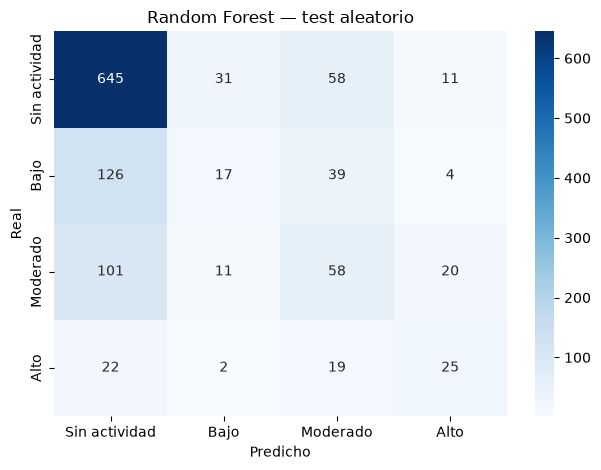

,precision,recall,f1-score,support
Sin actividad,0.7215,0.8658,0.7871,745.0
Bajo,0.2787,0.0914,0.1377,186.0
Moderado,0.3333,0.3053,0.3187,190.0
Alto,0.4167,0.3676,0.3906,68.0


In [10]:
cmtest=confusion_matrix(test[TARGET],ptest,labels=ORDEN);display(pd.DataFrame(cmtest,index=ORDEN,columns=ORDEN));sns.heatmap(cmtest,annot=True,fmt="d",cmap="Blues",xticklabels=ORDEN,yticklabels=ORDEN);plt.title(f"{ELEGIDO} — test aleatorio");plt.xlabel("Predicho");plt.ylabel("Real");plt.tight_layout();plt.show();pd.DataFrame(classification_report(test[TARGET],ptest,labels=ORDEN,output_dict=True,zero_division=0)).T.loc[ORDEN].round(4)

## 6. Importancia por permutación

Mide caída de F1 macro; no implica causalidad ni se usa para reconfigurar el modelo.

,variable,media,std
10,promedio_detecciones_ultimas_4_semanas,0.0492,0.0098
3,relative_humidity_2m_min_mean_weekly,0.0326,0.0114
1,mes,0.0277,0.0072
6,cantidad_detecciones_lag1,0.0183,0.0060
2,temperature_2m_max_mean_weekly,0.0174,0.0088
0,departamento,0.0156,0.0055
11,max_detecciones_ultimas_4_semanas,0.0111,0.0059
7,cantidad_detecciones_lag2,0.0096,0.0058
12,semanas_con_actividad_ultimas_4,0.0077,0.0054
5,precipitation_sum_weekly,0.0073,0.0117


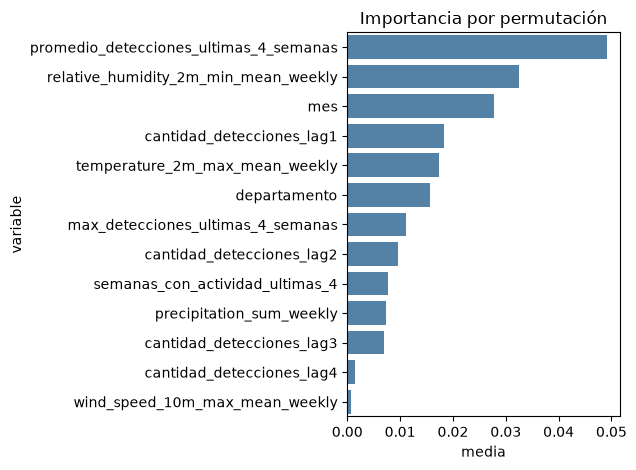

In [11]:
pi=permutation_importance(final,test[XCOL],test[TARGET],scoring="f1_macro",n_repeats=10,random_state=RS,n_jobs=-1);imp=pd.DataFrame({"variable":XCOL,"media":pi.importances_mean,"std":pi.importances_std}).sort_values("media",ascending=False);display(imp.round(4));sns.barplot(data=imp,y="variable",x="media",color="steelblue");plt.title("Importancia por permutación");plt.tight_layout();plt.show()

## 7. Evaluación temporal adicional

El mismo modelo congelado se ajusta con 2018–2024 y se evalúa en 2025. El resultado no modifica la solución.

In [12]:
trt=datos.loc[datos.anio.le(2024)];tet=datos.loc[datos.anio.eq(2025)];mt=clone(modelos[ELEGIDO]).fit(trt[XCOL],trt[TARGET]);pt=mt.predict(tet[XCOL]);mtemp=pd.Series(metr(tet[TARGET],pt),name="Test temporal 2025");mtemp.round(4)

Accuracy             0.6347
Balanced Accuracy    0.3955
Precision macro      0.4636
Recall macro         0.3955
F1 macro             0.4057
F1 weighted          0.5929
Name: Test temporal 2025, dtype: float64

,Sin actividad,Bajo,Moderado,Alto
Sin actividad,537,23,48,5
Bajo,105,11,33,2
Moderado,78,9,49,7
Alto,22,3,19,18


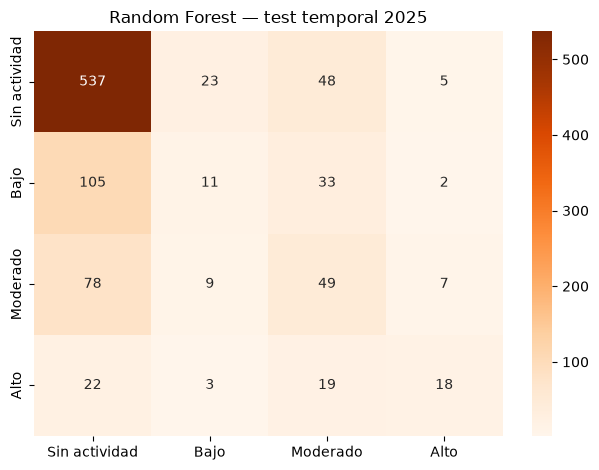

In [13]:
cmt=confusion_matrix(tet[TARGET],pt,labels=ORDEN);display(pd.DataFrame(cmt,index=ORDEN,columns=ORDEN));sns.heatmap(cmt,annot=True,fmt="d",cmap="Oranges",xticklabels=ORDEN,yticklabels=ORDEN);plt.title(f"{ELEGIDO} — test temporal 2025");plt.tight_layout();plt.show()

## 8. Comparación y errores

In [14]:
comp=pd.concat([tabval.assign(Evaluacion="Validation").reset_index(names="Modelo"),mtest.to_frame().T.assign(Modelo=ELEGIDO,Evaluacion="Test aleatorio"),mtemp.to_frame().T.assign(Modelo=ELEGIDO,Evaluacion="Test temporal 2025")],ignore_index=True);comp[["Evaluacion","Modelo","Accuracy","Balanced Accuracy","Precision macro","Recall macro","F1 macro","F1 weighted"]].round(4)

,Evaluacion,Modelo,Accuracy,Balanced Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted
0,Validation,Dummy,0.6271,0.2500,0.1568,0.2500,0.1927,0.4834
1,Validation,Regresión Logística,0.4773,0.4126,0.3507,0.4126,0.3528,0.5099
2,Validation,Random Forest,0.6094,0.3645,0.4073,0.3645,0.3660,0.5586
3,Test aleatorio,Random Forest,0.6266,0.4075,0.4375,0.4075,0.4085,0.5880
4,Test temporal 2025,Random Forest,0.6347,0.3955,0.4636,0.3955,0.4057,0.5929


In [15]:
err=test[["departamento","fecha_inicio_semana",TARGET]].copy();err["prediccion"]=ptest;err["correcto"]=err[TARGET].eq(err.prediccion);display(err.groupby("departamento").correcto.agg(observaciones="size",accuracy="mean").sort_values("accuracy").round(3));cod={x:i for i,x in enumerate(ORDEN)};(err[TARGET].map(cod)-err.prediccion.map(cod)).abs().value_counts(normalize=True).sort_index().rename("proporción")

,observaciones,accuracy
departamento,,
Soriano,60,0.450
Treinta y Tres,53,0.509
Canelones,72,0.514
San José,72,0.514
Lavalleja,58,0.534
Rocha,74,0.541
Artigas,59,0.542
Río Negro,73,0.589
Cerro Largo,54,0.611


0    0.626577
1    0.206897
2    0.138772
3    0.027754
Name: proporción, dtype: float64

## Conclusión

Las evaluaciones aleatoria y temporal se reportan por separado. El target es una discretización estadística; los lags requieren disponibilidad oportuna de FIRMS y la meteorología contemporánea requeriría observación durante la semana o pronósticos equivalentes para anticipación operativa.